In [ ]:
!pip install infomap --quiet
!pip install igraph --quiet
!pip install networkx>=3.2.1 --quiet

# Import các module hệ thống, đo thời gian, thư viện phân tích cấu trúc mạng và phát hiện cộng đồng.

In [ ]:
import os
import time
import pandas as pd
import networkx as nx
from google.colab import drive
from infomap import Infomap
import infomap
import igraph as ig

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PATH = "/content/drive/MyDrive/Social Network Analysis/Data/preprocessed/amazon0302_cleaned.txt"

# LoadData

In [ ]:
class LoadData:
    def __init__(self, file_path):
        self.file_path = file_path
        self.graph = nx.DiGraph()

    def load(self):
        with open(self.file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith('#'):
                    continue

                parts = line.split()
                if len(parts) == 2:
                    u, v = map(int, parts)
                    self.graph.add_edge(u, v)

        return self.graph

In [ ]:
loader = LoadData(PATH)
G = loader.load()

# Định nghĩa lớp Evaluator để tính toán các chỉ số đánh giá chất lượng cộng đồng như Modularity, Coverage, Conductance và Density.

In [ ]:
class Evaluator:
    def __init__(self, graph):
        self.G = graph
        self.num_nodes = graph.number_of_nodes()
        self.num_edges = graph.number_of_edges()

    def evaluate(self, name, communities, runtime):
        try:
            mod = nx.community.modularity(self.G, communities)
        except:
            mod = 0.0

        intra_edges = 0
        for comm in communities:
            subgraph = self.G.subgraph(comm)
            intra_edges += subgraph.number_of_edges()

        cov = intra_edges / self.num_edges if self.num_edges > 0 else 0.0

        total_conductance = 0.0
        total_internal_density = 0.0

        num_comm = len(communities)
        m = self.num_edges
        degrees = dict(self.G.degree())
        total_vol = 2 * m

        for comm in communities:
            comm_nodes = set(comm)
            n_c = len(comm_nodes)

            if n_c == 0:
                continue

            sub_g = self.G.subgraph(comm_nodes)

            internal_edges = sub_g.number_of_edges()
            vol_c = sum(degrees[node] for node in comm_nodes)

            cut_edges = vol_c - (2 * internal_edges)
            vol_not_c = total_vol - vol_c

            # Internal Density
            if n_c > 1:
                den_c = internal_edges / (n_c * (n_c - 1) / 2)
            else:
                den_c = 1.0

            total_internal_density += den_c

            # Conductance
            min_vol = min(vol_c, vol_not_c)
            cond_c = cut_edges / min_vol if min_vol > 0 else 0.0

            total_conductance += cond_c

        avg_conductance = (
            total_conductance / num_comm
            if num_comm > 0 else 0.0
        )

        avg_internal_density = (
            total_internal_density / num_comm
            if num_comm > 0 else 0.0
        )

        return {
            "Algorithm": name,
            "Runtime (s)": round(runtime, 4),
            "Community": num_comm,
            "Modularity": round(mod, 6),
            "Coverage": round(cov, 6),
            "Avg Conductance": round(avg_conductance, 6),
            "Avg Internal Density": round(avg_internal_density, 6)
        }

# Xây dựng lớp bọc cho thuật toán Infomap nhằm thực hiện phát hiện cộng đồng dựa trên dòng chảy thông tin.

In [ ]:
class Infomap:
    def __init__(self, options="--two-level --silent"):
        self.options = options

    def detect(self, G):
        # Use the actual library class
        im = infomap.Infomap(self.options)

        for u, v in G.edges():
            im.add_link(u, v)

        start_time = time.time()
        im.run()
        runtime = time.time() - start_time

        community_dict = {}
        for node in im.tree:
            if node.is_leaf:
                community_dict.setdefault(node.module_id, []).append(node.node_id)

        communities = [
            frozenset(nodes)
            for nodes in community_dict.values()
        ]

        return communities, runtime

# Label Propagation
Xây dựng lớp bọc cho thuật toán trên đồ thị vô hướng.

In [ ]:
class LabelPropagation:
    def detect(self, G):
        start_time = time.time()

        # Label propagation in NetworkX is only implemented for undirected graphs
        # We convert to undirected for this specific step
        if G.is_directed():
            communities = list(
                nx.community.label_propagation_communities(G.to_undirected())
            )
        else:
            communities = list(
                nx.community.label_propagation_communities(G)
            )

        runtime = time.time() - start_time

        return communities, runtime

 **Xây dựng lớp cấu hình thuật toán Leiden thông qua thư viện igraph nhằm tối ưu hóa hàm Modularity.**

In [ ]:
class Leiden:
    def __init__(self, objective_function="modularity", beta=1.0):
        self.objective_function = objective_function
        self.beta = beta

    def detect(self, G):
        start_time = time.time()

        ig_graph = ig.Graph.from_networkx(G)

        partition = ig_graph.community_leiden(
            objective_function=self.objective_function,
            beta=self.beta
        )

        communities = []
        for cluster in partition:
            actual_nodes = [
                ig_graph.vs[node_idx]["_nx_name"]
                for node_idx in cluster
            ]
            communities.append(frozenset(actual_nodes))

        runtime = time.time() - start_time

        return communities, runtime

# Xây dựng hệ thống Benchmark

In [ ]:
class Benchmark:
    def __init__(self, graph):
        self.G = graph
        self.evaluator = Evaluator(graph)
        self.results = []

    def run(self, algorithms):
        self.results = []

        for algo in algorithms:
            communities, runtime = algo.detect(self.G)

            name = algo.__class__.__name__

            result = self.evaluator.evaluate(
                name,
                communities,
                runtime
            )

            self.results.append(result)

        return self.results

    def to_dataframe(self):
        df = pd.DataFrame(self.results)

        columns_order = [
            "Algorithm",
            "Runtime (s)",
            "Community",
            "Modularity",
            "Coverage",
            "Avg Conductance",
            "Avg Internal Density",
        ]

        return df[columns_order]

# So sánh các thuật toán

In [ ]:
benchmark = Benchmark(G)

algorithms = [
    Infomap(),
    LabelPropagation(),
    Leiden()
]

benchmark.run(algorithms)

df_results = benchmark.to_dataframe()

from IPython.display import display
display(df_results)

,Algorithm,Runtime (s),Community,Modularity,Coverage,Avg Conductance,Avg Internal Density
0,Infomap,14.1078,6733,0.845421,0.845790,0.142089,0.514561
1,LabelPropagation,22.2873,11635,0.746669,0.747016,0.270846,0.658115
2,Leiden,1.6577,583,0.937966,0.952977,0.013870,0.542321


# Hàm trực quan hóa cộng đồng

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig
import colorsys


def visualize_leiden_communities(
    G,
    communities,
    output_img_path,
    layout_name="drl",
    figsize=(25, 25),
    node_size=0.5,
    alpha=0.9,
    dpi=300
):
    """
    Visualize community detection result with highly distinct colors.

    Parameters
    ----------
    G : networkx.Graph
        Input graph.
    communities : list
        List of communities, each community is a set/list of nodes.
    output_img_path : str
        Output image path.
    layout_name : str, default='drl'
        igraph layout algorithm.
    figsize : tuple, default=(25,25)
        Figure size.
    node_size : float, default=0.5
        Node marker size.
    alpha : float, default=0.9
        Node transparency.
    dpi : int, default=300
        Output image resolution.
    """

    # Node -> Community mapping
    node_to_comm = {}
    for comm_id, comm_nodes in enumerate(communities):
        for node in comm_nodes:
            node_to_comm[node] = comm_id

    # Convert to igraph
    ig_graph = ig.Graph.from_networkx(G)

    communities_array = np.array([
        node_to_comm.get(v["_nx_name"], 0)
        for v in ig_graph.vs
    ])

    # Layout
    layout = ig_graph.layout(layout_name)
    coords = np.array(layout.coords)

    # Generate highly distinct colors
    num_communities = len(communities)

    color_list = []
    for i in range(num_communities):
        hue = ((i * 137.508) % 360) / 360.0
        r, g, b = colorsys.hsv_to_rgb(hue, 0.85, 0.85)
        color_list.append([r, g, b])

    color_matrix = np.array(color_list)
    node_colors = color_matrix[communities_array]

    # Plot
    fig, ax = plt.subplots(figsize=figsize, facecolor="white")

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=node_colors,
        s=node_size,
        alpha=alpha,
        edgecolors="none"
    )

    ax.axis("off")

    plt.savefig(
        output_img_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0,
        facecolor=fig.get_facecolor()
    )

    plt.close(fig)

# Hiển thị kết quả Leiden

In [ ]:
leiden_communities, _ = algorithms[2].detect(G)

# Ensure the filename has a valid extension and fix path
visualize_leiden_communities(
    G,
    communities=leiden_communities,
    output_img_path="/content/drive/MyDrive/Social Network Analysis/asset/preprocessed_community.png"
)

# Tạo DataFrame cộng đồng

In [ ]:
import pandas as pd

# Create a list of dictionaries mapping community index to node
community_data = []
for i, community in enumerate(leiden_communities):
    for node in community:
        community_data.append({"Community": i, "Node": node})

# Create the DataFrame
df_community_node = pd.DataFrame(community_data)

# Display the first few rows
display(df_community_node.head())

,Community,Node
0,0,4
1,0,24582
2,0,7
3,0,24584
4,0,24583


# Kiểm tra dữ liệu cộng đồng

In [ ]:
df_community_node

,Community,Node
0,0,4
1,0,24582
2,0,7
3,0,24584
4,0,24583
...,...,...
120733,564,261449
120734,564,261450
120735,564,261500
120736,564,261470


In [ ]:
# Group nodes by community to have one row per unique community ID
df_community_grouped = df_community_node.groupby('Community')['Node'].apply(list).reset_index()

# Display the reformatted DataFrame
display(df_community_grouped.head())

,Community,Node
0,0,"[4, 24582, 7, 24584, 24583, 24585, 49163, 4916..."
1,1,"[28674, 194980, 8196, 8197, 8198, 8199, 26633,..."
2,2,"[61975, 61722, 61723, 178844, 175520, 78625, 7..."
3,3,"[12292, 88069, 12293, 36871, 18439, 18440, 471..."
4,4,"[40961, 40962, 98307, 40963, 5, 6, 98305, 8, 1..."


# Tính toán đặc trưng cộng đồng

In [ ]:
import networkx as nx

def get_community_metrics(nodes):
    subgraph = G.subgraph(nodes)
    size = subgraph.number_of_nodes()

    # Density
    if size > 1:
        density = nx.density(subgraph)
    else:
        density = 0.0

    return size, density

# Apply the function to each community
metrics = df_community_grouped['Node'].apply(get_community_metrics)

# Unpack the results into new columns
df_community_grouped[['Size', 'Density']] = pd.DataFrame(
    metrics.tolist(),
    index=df_community_grouped.index
)

# Display the updated DataFrame
display(df_community_grouped.head())

,Community,Node,Size,Density
0,0,"[4, 24582, 7, 24584, 24583, 24585, 49163, 4916...",2474,0.001334
1,1,"[28674, 194980, 8196, 8197, 8198, 8199, 26633,...",996,0.003361
2,2,"[61975, 61722, 61723, 178844, 175520, 78625, 7...",33,0.107955
3,3,"[12292, 88069, 12293, 36871, 18439, 18440, 471...",596,0.005417
4,4,"[40961, 40962, 98307, 40963, 5, 6, 98305, 8, 1...",3072,0.001112


# Lưu kết quả cộng đồng

In [ ]:
import os

# Define the output directory and file path
output_dir = '/content/drive/MyDrive/Social Network Analysis/Data/community'
output_file = os.path.join(output_dir, 'df_community_grouped.csv')

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Export the DataFrame
df_community_grouped.to_csv(output_file, index=False)

print(f"DataFrame exported successfully to: {output_file}")

DataFrame exported successfully to: /content/drive/MyDrive/Social Network Analysis/Data/community/df_community_grouped.csv


# Phân tích kích thước cộng đồng

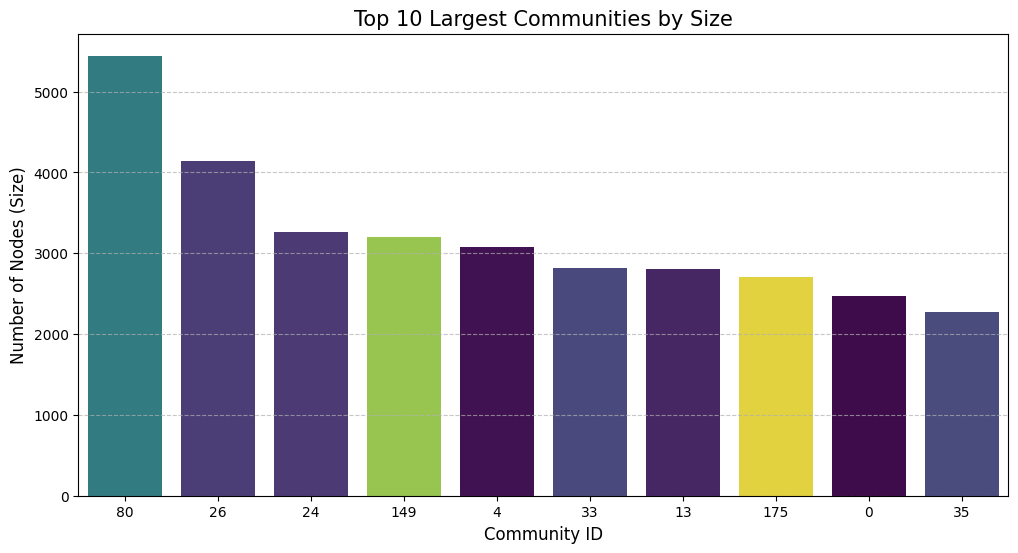

,Community,Size,Density
80,80,5444,0.000692
26,26,4146,0.000848
24,24,3261,0.001037
149,149,3199,0.001065
4,4,3072,0.001112
33,33,2814,0.001196
13,13,2804,0.001259
175,175,2707,0.001311
0,0,2474,0.001334
35,35,2278,0.001431


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 communities by size
top_10_communities = df_community_grouped.nlargest(10, 'Size')

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Community',
    y='Size',
    data=top_10_communities,
    hue='Community',
    palette='viridis',
    order=top_10_communities['Community'],
    legend=False
)

plt.title('Top 10 Largest Communities by Size', fontsize=15)
plt.xlabel('Community ID', fontsize=12)
plt.ylabel('Number of Nodes (Size)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Display the top 10 data table
display(top_10_communities[['Community', 'Size', 'Density']])

# Xây dựng Meta-Graph

Visualization exported to: /content/drive/MyDrive/Social Network Analysis/asset/community_interaction_graph.png


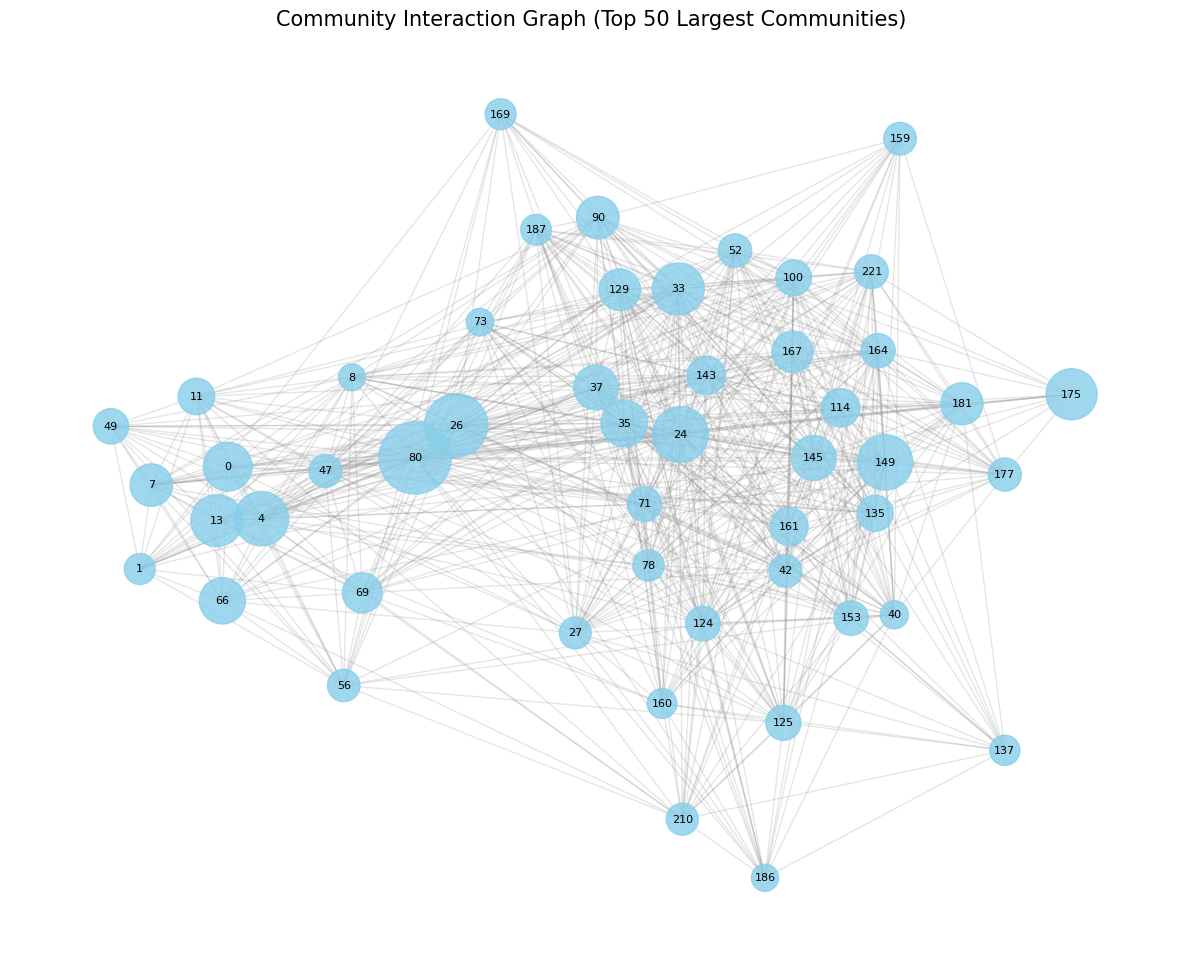

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import os

# 1. Create a mapping of Node -> Community ID
node_to_comm = {}
for idx, row in df_community_grouped.iterrows():
    for node in row['Node']:
        node_to_comm[node] = row['Community']

# 2. Build the Meta-Graph (Community Graph)
CG = nx.Graph()

for u, v in G.edges():
    comm_u = node_to_comm.get(u)
    comm_v = node_to_comm.get(v)

    if comm_u is not None and comm_v is not None and comm_u != comm_v:
        if CG.has_edge(comm_u, comm_v):
            CG[comm_u][comm_v]['weight'] += 1
        else:
            CG.add_edge(comm_u, comm_v, weight=1)

# 3. Filter for visualization (top 50 largest communities)
top_n = 50
top_communities = df_community_grouped.nlargest(top_n, 'Size')['Community'].tolist()
sub_CG = CG.subgraph(top_communities)

# 4. Plotting
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(sub_CG, k=0.5, seed=42)

# Node sizes based on community size
sizes = [df_community_grouped.loc[df_community_grouped['Community'] == n, 'Size'].values[0] / 2 for n in sub_CG.nodes()]

# Draw
nx.draw_networkx_nodes(sub_CG, pos, node_size=sizes, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(sub_CG, pos, alpha=0.2, edge_color='gray')
nx.draw_networkx_labels(sub_CG, pos, font_size=8)

plt.title(f'Community Interaction Graph (Top {top_n} Largest Communities)', fontsize=15)
plt.axis('off')

# 5. Export to asset folder
output_path = "/content/drive/MyDrive/Social Network Analysis/asset/community_interaction_graph.png"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Visualization exported to: {output_path}")

plt.show()